In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

%load_ext autoreload
%autoreload 2
from survey_medley_code.config_loader import load_config
from survey_medley_code.within_subject_modeling.io_utils import (
    get_confounds_data,
    get_subids_bids_dir,
    load_tsv_data,
    resolve_file,
)

In [2]:
cfg = load_config()
subids = get_subids_bids_dir(cfg)

In [3]:
all_events = []

for subid in subids:
    try:
        # Try to get the behavioral file
        behav_file = resolve_file(cfg, subid, 'behav')
    except ValueError:
        print(f'Skipping sub-{subid}: behav file not found')
        continue

    # Load the events data
    events = load_tsv_data(behav_file)
    events['subid'] = subid  # Add subid column
    all_events.append(events)

# Concatenate all events into a single DataFrame
events_df = pd.concat(all_events, ignore_index=True)

Skipping sub-s144: behav file not found
Skipping sub-s533: behav file not found
Skipping sub-s600: behav file not found
Skipping sub-s603: behav file not found
Skipping sub-s639: behav file not found
Skipping sub-s640: behav file not found


In [4]:
events_df.head()

,onset,duration,coded_response,experiment_exp_id,item_coding,item_text,key_press,possible_responses,response_time,survey,trial_type,worker_id,subid
0,1.004,8.5,0.250000,survey_medley,reverse,Pleasure and fun sometimes keep me from gettin...,82,"66,89,71,82,77",6.139,brief,Q17,s061,s061
1,10.210,8.5,0.666667,survey_medley,reverse,"Sometimes when I feel bad, I can't seem to sto...",89,"66,89,71,82",8.230,upps,Q32,s061,s061
2,19.415,8.5,0.500000,survey_medley,forward,I am good at resisting temptation.,71,"66,89,71,82,77",4.710,brief,Q09,s061,s061
3,28.688,8.5,0.500000,survey_medley,reverse,New ideas and projects sometimes distract me f...,71,"66,89,71,82,77",5.678,grit,Q01,s061,s061
4,37.894,8.5,0.500000,survey_medley,reverse,There are only limited possibilities in my fut...,71,"66,89,71,82,77",4.869,future_time,Q30,s061,s061


In [5]:
events_df.columns

Index(['onset', 'duration', 'coded_response', 'experiment_exp_id',
       'item_coding', 'item_text', 'key_press', 'possible_responses',
       'response_time', 'survey', 'trial_type', 'worker_id', 'subid'],
      dtype='object')

/tmp/ipykernel_24754/788667872.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


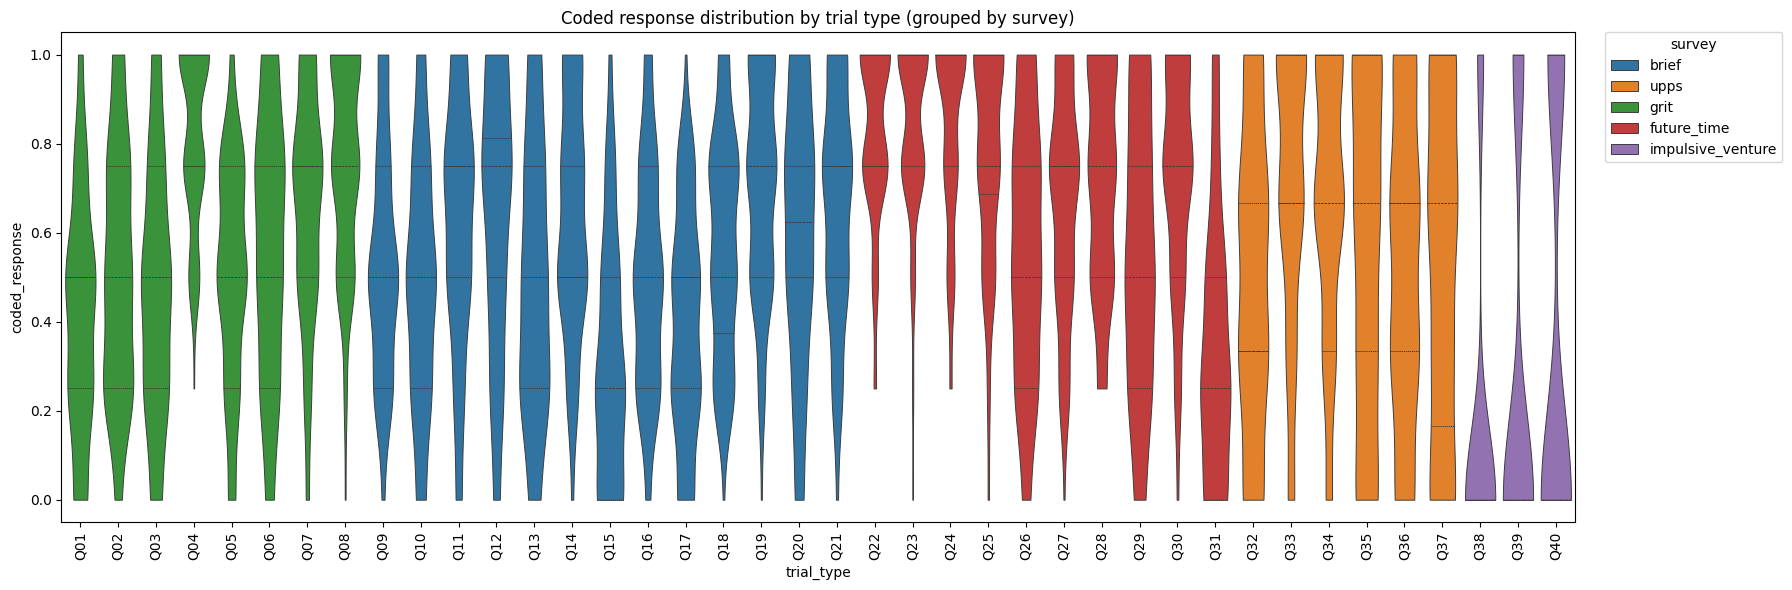

In [6]:
# Violin plot of coded_response by trial_type, colored by survey
plot_df = events_df.copy()
plot_df = plot_df.dropna(subset=['coded_response', 'trial_type', 'survey'])
plot_df['coded_response'] = pd.to_numeric(plot_df['coded_response'], errors='coerce')
plot_df = plot_df.dropna(subset=['coded_response'])
trial_order = sorted(plot_df['trial_type'].unique())

plt.figure(figsize=(18, 6))
ax = sns.violinplot(
    data=plot_df,
    x='trial_type',
    y='coded_response',
    hue='survey',
    order=trial_order,
    cut=0,
    inner='quartile',
    linewidth=0.7,
    scale='width',
)
ax.set_xlabel('trial_type')
ax.set_ylabel('coded_response')
ax.set_title('Coded response distribution by trial type (grouped by survey)')
ax.tick_params(axis='x', rotation=90)
ax.legend(title='survey', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

In [18]:
events_df

,onset,duration,coded_response,experiment_exp_id,item_coding,item_text,key_press,possible_responses,response_time,survey,trial_type,worker_id,subid
0,1.004,8.5,0.250000,survey_medley,reverse,Pleasure and fun sometimes keep me from gettin...,82,"66,89,71,82,77",6.139,brief,Q17,s061,s061
1,10.210,8.5,0.666667,survey_medley,reverse,"Sometimes when I feel bad, I can't seem to sto...",89,"66,89,71,82",8.230,upps,Q32,s061,s061
2,19.415,8.5,0.500000,survey_medley,forward,I am good at resisting temptation.,71,"66,89,71,82,77",4.710,brief,Q09,s061,s061
3,28.688,8.5,0.500000,survey_medley,reverse,New ideas and projects sometimes distract me f...,71,"66,89,71,82,77",5.678,grit,Q01,s061,s061
4,37.894,8.5,0.500000,survey_medley,reverse,There are only limited possibilities in my fut...,71,"66,89,71,82,77",4.869,future_time,Q30,s061,s061
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4155,351.389,8.5,0.333333,survey_medley,reverse,"When I get really happy about something, I ten...",71,"66,89,71,82,77",1.424,upps,Q34,s650,s650
4156,360.460,8.5,0.500000,survey_medley,forward,My future seems infinite to me.,71,"66,89,71,82,77",3.959,future_time,Q26,s650,s650
4157,370.619,8.5,NaN,survey_medley,reverse,"Sometimes when I feel bad, I can't seem to sto...",-1,"66,89,71,82,77",NaN,upps,Q32,s650,s650
4158,380.506,8.5,NaN,survey_medley,reverse,I wish I had more self-discipline.,-1,"66,89,71,82,77",NaN,brief,Q15,s650,s650


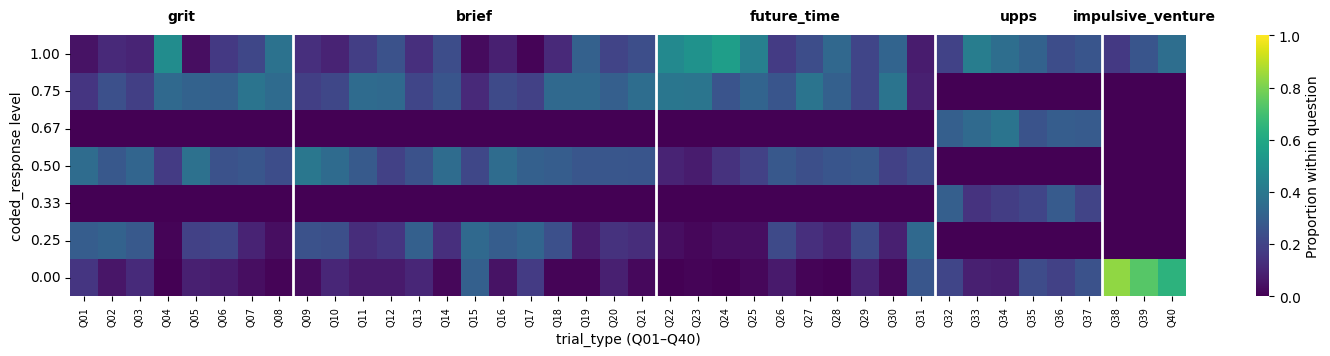

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plot_df = events_df.dropna(subset=['coded_response', 'trial_type', 'survey']).copy()
plot_df['coded_response'] = pd.to_numeric(plot_df['coded_response'], errors='coerce')
plot_df = plot_df.dropna(subset=['coded_response'])

levels = np.sort(plot_df['coded_response'].unique())

# counts
counts = (
    plot_df.groupby(['trial_type', 'survey', 'coded_response'])
    .size()
    .rename('n')
    .reset_index()
)

# column order: just question order
col_order_df = (
    plot_df[['trial_type', 'survey']]
    .drop_duplicates()
    .sort_values(['trial_type'])  # relies on Q01..Q40 zero padding
)
col_order = col_order_df['trial_type'].tolist()

# matrix
M = counts.pivot_table(
    index='coded_response',
    columns='trial_type',
    values='n',
    fill_value=0,
).reindex(index=levels, columns=col_order)

M_prop = M / M.sum(axis=0).replace(0, np.nan)

plt.figure(figsize=(18, 4.5))
ax = sns.heatmap(
    M_prop,
    cmap='viridis',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Proportion within question'},
)
ax.invert_yaxis()

ax.set_xlabel('trial_type (Q01–Q40)')
ax.set_ylabel('coded_response level')

# y tick labels
ax.set_yticklabels([f'{v:.2f}' for v in M_prop.index.to_numpy()], rotation=0)

# boundaries where survey changes as we move across trial_type
survey_by_col = col_order_df.set_index('trial_type').loc[col_order, 'survey'].values
boundaries = np.where(survey_by_col[:-1] != survey_by_col[1:])[0] + 1
for b in boundaries:
    ax.axvline(b, color='white', lw=2)

# x tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)

# survey labels centered under each contiguous block (robust to invert_yaxis)
start = 0
blocks = []
for b in list(boundaries) + [len(col_order)]:
    blocks.append((start, b))
    start = b

for s, e in blocks:
    survey_name = survey_by_col[s]
    x_mid = (s + e) / 2.0
    ax.text(
        x_mid,
        1.1,
        survey_name,
        ha='center',
        va='top',
        fontsize=10,
        fontweight='bold',
        transform=ax.get_xaxis_transform(),  # x=data coords, y=axes coords
        clip_on=False,
    )

plt.subplots_adjust(bottom=0.30)
plt.show()


In [8]:
from itertools import combinations

from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

df = events_df.copy()

sub_means = (
    df.groupby(['subid', 'survey'], as_index=False)['coded_response']
    .mean()
    .rename(columns={'coded_response': 'mean_coded_response'})
)

wide = sub_means.pivot(index='subid', columns='survey', values='mean_coded_response')
surveys = list(wide.columns)

rows = []
for a, b in combinations(surveys, 2):
    tmp = wide[[a, b]].dropna()
    t, p = ttest_rel(tmp[a], tmp[b])
    rows.append(
        {
            'survey_a': a,
            'survey_b': b,
            'n_sub': int(len(tmp)),
            'mean_diff': float((tmp[a] - tmp[b]).mean()),
            't': float(t),
            'F': float(t**2),
            'p_unc': float(p),
        }
    )

pairwise = pd.DataFrame(rows).sort_values('p_unc').reset_index(drop=True)
pairwise['p_holm'] = multipletests(pairwise['p_unc'].values, method='holm')[1]
pairwise['p_fdr_bh'] = multipletests(pairwise['p_unc'].values, method='fdr_bh')[1]
pairwise

,survey_a,survey_b,n_sub,mean_diff,t,F,p_unc,p_holm,p_fdr_bh
0,future_time,impulsive_venture,90,0.415872,10.292402,105.933532,7.987894e-17,7.987894e-16,7.987894e-16
1,grit,impulsive_venture,90,0.320767,8.404096,70.628832,6.407189e-13,5.766470e-12,3.203594e-12
2,impulsive_venture,upps,90,-0.316358,-7.785250,60.610123,1.195565e-11,9.564523e-11,3.985218e-11
3,brief,future_time,104,-0.134332,-7.484839,56.022815,2.509964e-11,1.756975e-10,6.274909e-11
4,brief,impulsive_venture,90,0.282001,7.462156,55.683769,5.435237e-11,3.261142e-10,1.087047e-10
5,future_time,grit,104,0.093480,5.229000,27.342443,8.982217e-07,4.491109e-06,1.497036e-06
6,future_time,upps,104,0.118650,4.653473,21.654814,9.745123e-06,3.898049e-05,1.392160e-05
7,brief,grit,104,-0.040852,-3.034148,9.206056,3.053491e-03,9.160472e-03,3.816863e-03
8,grit,upps,104,0.025170,1.114221,1.241489,2.677776e-01,5.355552e-01,2.975307e-01
9,brief,upps,104,-0.015682,-0.768959,0.591298,4.436771e-01,5.355552e-01,4.436771e-01


In [10]:
import pandas as pd


def format_p(p):
    if p < 1e-16:
        return '<1e-16'
    if p < 1e-6:
        return f'{p:.1e}'
    if p < 1e-3:
        return f'{p:.2e}'
    return f'{p:.4f}'


pretty = pairwise.copy()

# choose correction
p_adj = pairwise['p_holm'].values

pretty['p_adj(Holm)'] = pairwise['p_holm'].map(format_p)
pretty['reject(p<.05)'] = p_adj < 0.05


def direction_named(row):
    a, b, d = row['survey_a'], row['survey_b'], row['mean_diff']
    if d > 0:
        return f'{b} < {a}'  # always "<"
    if d < 0:
        return f'{a} < {b}'
    return f'{a} = {b}'


pretty['direction'] = pretty.apply(direction_named, axis=1)


# human-readable interpretation
def interp(row):
    a, b = row['survey_a'], row['survey_b']
    d = row['mean_diff']
    if row['reject(p<.05)']:
        if d > 0:
            return f'Reject H0: mean({b}) < mean({a})'
        if d < 0:
            return f'Reject H0: mean({a}) < mean({b})'
        return 'Reject H0: means differ (diff≈0)'
    return f'Fail to reject H0: no evidence mean({a}) ≠ mean({b})'


pretty['interpretation'] = pretty.apply(interp, axis=1)

# formatting for display
pretty['mean_diff'] = pretty['mean_diff'].map(lambda x: f'{x:+.3f}')
pretty['t'] = pretty['t'].map(lambda x: f'{x:+.2f}')
pretty['n_sub'] = pretty['n_sub'].astype(int)

pretty_disp = pretty[
    [
        'survey_a',
        'survey_b',
        'n_sub',
        'mean_diff',
        'direction',
        't',
        'p_adj(Holm)',
        'reject(p<.05)',
        'interpretation',
    ]
].sort_values(['reject(p<.05)', 'p_adj(Holm)'], ascending=[False, True])

print(pretty_disp.to_markdown(index=False))

| survey_a          | survey_b          |   n_sub |   mean_diff | direction                       |     t |   p_adj(Holm) | reject(p<.05)   | interpretation                                          |
|:------------------|:------------------|--------:|------------:|:--------------------------------|------:|--------------:|:----------------|:--------------------------------------------------------|
| brief             | grit              |     104 |      -0.041 | brief < grit                    | -3.03 |      0.0092   | True            | Reject H0: mean(brief) < mean(grit)                     |
| brief             | future_time       |     104 |      -0.134 | brief < future_time             | -7.48 |      1.8e-10  | True            | Reject H0: mean(brief) < mean(future_time)              |
| brief             | impulsive_venture |      90 |       0.282 | impulsive_venture < brief       |  7.46 |      3.3e-10  | True            | Reject H0: mean(impulsive_venture) < mean(brief)        |


| survey_a          | survey_b          |   n_sub |   mean_diff | direction                       |     t |   p_adj(Holm) | reject(p<.05)   | interpretation                                          |
|:------------------|:------------------|--------:|------------:|:--------------------------------|------:|--------------:|:----------------|:--------------------------------------------------------|
| brief             | grit              |     104 |      -0.041 | brief < grit                    | -3.03 |      0.0092   | True            | Reject H0: mean(brief) < mean(grit)                     |
| brief             | future_time       |     104 |      -0.134 | brief < future_time             | -7.48 |      1.8e-10  | True            | Reject H0: mean(brief) < mean(future_time)              |
| brief             | impulsive_venture |      90 |       0.282 | impulsive_venture < brief       |  7.46 |      3.3e-10  | True            | Reject H0: mean(impulsive_venture) < mean(brief)        |
| future_time       | upps              |     104 |       0.119 | upps < future_time              |  4.65 |      3.9e-05  | True            | Reject H0: mean(upps) < mean(future_time)               |
| future_time       | grit              |     104 |       0.093 | grit < future_time              |  5.23 |      4.49e-06 | True            | Reject H0: mean(grit) < mean(future_time)               |
| grit              | impulsive_venture |      90 |       0.321 | impulsive_venture < grit        |  8.4  |      5.8e-12  | True            | Reject H0: mean(impulsive_venture) < mean(grit)         |
| future_time       | impulsive_venture |      90 |       0.416 | impulsive_venture < future_time | 10.29 |      8e-16    | True            | Reject H0: mean(impulsive_venture) < mean(future_time)  |
| impulsive_venture | upps              |      90 |      -0.316 | impulsive_venture < upps        | -7.79 |      9.6e-11  | True            | Reject H0: mean(impulsive_venture) < mean(upps)         |
| grit              | upps              |     104 |       0.025 | upps < grit                     |  1.11 |      0.5356   | False           | Fail to reject H0: no evidence mean(grit) ≠ mean(upps)  |
| brief             | upps              |     104 |      -0.016 | brief < upps                    | -0.77 |      0.5356   | False           | Fail to reject H0: no evidence mean(brief) ≠ mean(upps) |